#### 대여소별 수요 회귀 모델 (1년치로 확장)

- `data/서울특별시 공공자전거 이용정보(시간대별)_*.csv` — 작년 7월 ~ 올해 6월, 월별로 나뉜 12개 파일
- `data/공공자전거 대여소 정보(26.6월 기준).xlsx` — 대여소 번호별 위치/거치대 수 (대여소 번호로만 조인해서 피처 추가)
- `data/weather/*.csv` — 기상청에서 받은 같은 1년 구간의 시간별 관측 데이터 (기온/강수량/풍속/습도)

이 노트북은 두 개의 모델을 만듭니다.
1. **대여소 수요 모델** — "이 대여소가, 이 시간대에, 평소 몇 건 정도 대여되는지" (요일·시간·대여소 패턴, 날씨 미포함)
2. **날씨 효과 모델** — "오늘 날씨가 평소 대비 전체 대여량을 몇 배로 만드는지" (도시 전체 총량 기준)

이전 버전(6월 한 달) 대비 달라진 점:
- `usage`, `station demand` 학습 데이터가 1년치로 확장됨 → `month` 피처 추가로 계절성 반영
- `weather_effect_model`도 이 노트북 안에서 직접, 같은 1년치 데이터로 재학습 (더 이상 별도로 몰래 만들어진 pkl이 아님)
- 모든 원본 컬럼은 먼저 있는 그대로 출력해서 확인한 뒤 매핑 (임의 가정 금지 원칙 유지)

#### 1. 라이브러리 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

pd.set_option('display.max_columns', None)

#### 2. 데이터 불러오기 대여소별 이용 시간대별

In [2]:
import glob

usage_files = sorted(glob.glob('../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_*.csv'))
print(f'{len(usage_files)}개 파일 발견')
for f in usage_files:
    print(' -', f)

# 12개월치를 전부 이어붙이기 전에, 컬럼 구성이 매달 동일한지 먼저 확인합니다.
# (연도가 바뀌는 시점에 컬럼명/순서가 달라지는 경우가 종종 있어서, 여기서 미리 검증)
column_sets = {}
for f in usage_files:
    try:
        head = pd.read_csv(f, encoding='cp949', nrows=5)
    except UnicodeDecodeError:
        head = pd.read_csv(f, encoding='utf-8', nrows=5)
    column_sets[f] = tuple(head.columns)

unique_column_sets = set(column_sets.values())
print(f'\n서로 다른 컬럼 구성 종류: {len(unique_column_sets)}개')
if len(unique_column_sets) > 1:
    print('⚠️ 파일마다 컬럼 구성이 다릅니다. 아래에서 어떤 파일이 다른지 확인하세요.')
    for f, cols in column_sets.items():
        print(f, '->', cols)
else:
    print('모든 파일의 컬럼 구성이 동일합니다:', list(unique_column_sets)[0])

12개 파일 발견
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202507.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202508.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202509.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202510.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202511.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202512.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202601.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202602.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202603.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202604.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202605.csv
 - ../data/대여소 시간별/서울특별시 공공자전거 이용정보(시간대별)_202606.csv

서로 다른 컬럼 구성 종류: 1개
모든 파일의 컬럼 구성이 동일합니다: ('대여일자', '대여시간', '대여소번호', '대여소명', '대여구분코드', '성별', '연령대코드', '이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)')


In [4]:
def _read_usage_csv(path):
    for enc in ('cp949', 'utf-8'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('cp949/utf-8 둘 다 실패', b'', 0, 1, path)

frames = [_read_usage_csv(f) for f in usage_files]
usage = pd.concat(frames, ignore_index=True)

# 월 파일 경계에 겹치는 행이 있을 수 있으니 완전 중복 행 제거
before = len(usage)
usage = usage.drop_duplicates()
print(f'중복 제거: {before}행 -> {len(usage)}행')
print('전체 기간:', usage['대여일자'].min(), '~', usage['대여일자'].max())
usage.shape

중복 제거: 34387753행 -> 34387753행
전체 기간: 2025-07-01 ~ 2026-06-30


(34387753, 12)

In [5]:
print('행/열:', usage.shape)
usage.info()

행/열: (34387753, 12)
<class 'pandas.DataFrame'>
RangeIndex: 34387753 entries, 0 to 34387752
Data columns (total 12 columns):
 #   Column   Dtype  
---  ------   -----  
 0   대여일자     str    
 1   대여시간     int64  
 2   대여소번호    int64  
 3   대여소명     str    
 4   대여구분코드   str    
 5   성별       str    
 6   연령대코드    str    
 7   이용건수     int64  
 8   운동량      str    
 9   탄소량      str    
 10  이동거리(M)  float64
 11  이용시간(분)  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 3.1 GB


#### 3. 데이터 불러오기 - 대여소

In [6]:
# 원본 엑셀의 '진짜' 컬럼을 먼저 있는 그대로 확인 (추측/가정 없이)
# header=3 위의 실제 헤더 행에 위도/경도, 동 단위 주소가 별도 컬럼으로 있는지 여기서 직접 확인합니다.
raw_station = pd.read_excel('../data/공공자전거 대여소 정보(26.6월 기준).xlsx', header=3)
print('원본 컬럼 목록:', list(raw_station.columns))
raw_station.head(10)

원본 컬럼 목록: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', '거치\n대수', '거치\n대수.1', 'Unnamed: 9']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,거치\n대수,거치\n대수.1,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102.0,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR
2,103.0,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR
3,104.0,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986,2015-09-06 23:44:31,NaN,13.0,QR
4,105.0,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825,2015-09-06 23:45:30,NaN,5.0,QR
5,106.0,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827,2015-09-06 23:46:31,NaN,12.0,QR
6,107.0,신한은행 서교동지점,마포구,서울특별시 마포구 월드컵북로 35,37.557510,126.918503,2015-09-06 23:47:57,NaN,5.0,QR
7,108.0,서교동 사거리,마포구,서울특별시 마포구 양화로 93,37.552746,126.918617,2015-09-06 23:51:25,NaN,10.0,QR
8,111.0,상수역 2번출구 앞,마포구,서울특별시 마포구 와우산로 40,37.547871,126.923531,2015-09-07 01:30:37,NaN,10.0,QR
9,113.0,홍대입구역 2번출구 앞,마포구,서울특별시 마포구 양화로 165,37.557438,126.923821,2015-09-07 01:32:58,NaN,25.0,QR


In [7]:
# ↑ 출력된 원본 컬럼명을 그대로 써서 매핑합니다 (임의로 만들지 않고, 실제 존재하는 컬럼만 이름만 정리).
# 주의: 아래 컬럼 개수/순서는 위 출력 결과를 보고 실제 컬럼 수에 맞게 반드시 조정해야 합니다.
# (이전 버전은 이 시점에서 addr1/addr2/addr3, 위도/경도 컬럼을 통째로 버리고 있었습니다 -> 그래서 '동'과
#  좌표가 결과물에 없었고, 이후 다른 곳에서 임의로 채워 넣게 된 것입니다.)
station = raw_station.copy()
station.columns = ['station_id','station_name','district','addr1','addr2','addr3',
                    'install_date','install_type','rack_count','operation_type']
station = station.dropna(subset=['station_id'])
station['station_id'] = station['station_id'].astype(int)

# 주소 원문 샘플을 직접 눈으로 확인 (동 이름이 어느 컬럼/어느 위치에 있는지 정제 전에 검증)
station[['station_id','station_name','district','addr1','addr2','addr3']].sample(15, random_state=1)

,station_id,station_name,district,addr1,addr2,addr3
232,394,경희궁 자이 3단지,종로구,서울특별시 종로구 경교장길 35 경희궁자이 3단지,37.567490,126.965919
1883,3586,군자역 비채온 오피스텔,광진구,서울특별시 광진구 군자동 473-26,37.557713,127.077271
956,1418,새솔초등학교,중랑구,서울특별시 중랑구 신내역로1길 164 새솔초등학교,37.617439,127.109016
686,1037,강일리버파크 6단지,강동구,서울특별시 강일동 448-2,37.562565,127.177612
1021,1525,미아동 복합청사,강북구,서울특별시 강북구 솔매로49길 14 미아동 195-1,37.627140,127.026695
1551,2396,영동3교 북단(우성캐릭터 앞 보도),강남구,강남구 도곡동 466,37.485741,127.051048
969,1435,능산삼거리,중랑구,서울특별시 중랑구 용마산로 644 능산삼거리,37.608681,127.100792
1711,2809,항동지구 11단지 1103동 앞,구로구,구로구 항동 169-1,37.477905,126.823112
2388,4573,두산위브아파트,영등포구,영등포구 신길로60나길 9,37.514702,126.912140
2550,4873,개롱역사거리 2번 출구,송파구,송파구 오금동 166,37.498272,127.134865


#### 6-1. '동' 추출 (외부 API/임의 CSV 없이, 원본 주소 컬럼에서 직접 파싱)

In [8]:
import re

def extract_dong(*addr_parts):
    """주소 문자열들에서 법정동/행정동 이름을 정규식으로 추출합니다.
    예: '서울특별시 강동구 암사동 123-4' -> '암사동'
    ※ 위 셀에서 addr1/addr2/addr3 샘플을 직접 확인한 뒤,
      실제 동 이름이 들어있는 패턴에 맞게 정규식을 조정하세요.
    """
    text = ' '.join(str(p) for p in addr_parts if pd.notna(p))
    # '~동' 또는 '~1동' 형태의 토큰을 찾되, 흔한 오탐(운동, 자동 등)은 제외
    match = re.search(r'([가-힣]{1,6}\d?동)(?=\s|$)', text)
    return match.group(1) if match else None

station['dong'] = station.apply(
    lambda r: extract_dong(r['addr1'], r['addr2'], r['addr3']), axis=1
)

print('동 추출 성공률:', station['dong'].notna().mean().__round__(3))
station[station['dong'].isna()][['station_id','station_name','addr1','addr2','addr3']].head(10)

동 추출 성공률: 0.347


,station_id,station_name,addr1,addr2,addr3
1,102,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72,37.555649,126.910629
2,103,망원역 2번출구 앞,서울특별시 마포구 월드컵로 79,37.554951,126.910835
3,104,합정역 1번출구 앞,서울특별시 마포구 양화로 59,37.550629,126.914986
4,105,합정역 5번출구 앞,서울특별시 마포구 양화로 48,37.550007,126.914825
5,106,합정역 7번출구 앞,서울특별시 마포구 독막로 4,37.548645,126.912827
6,107,신한은행 서교동지점,서울특별시 마포구 월드컵북로 35,37.557510,126.918503
7,108,서교동 사거리,서울특별시 마포구 양화로 93,37.552746,126.918617
8,111,상수역 2번출구 앞,서울특별시 마포구 와우산로 40,37.547871,126.923531
9,113,홍대입구역 2번출구 앞,서울특별시 마포구 양화로 165,37.557438,126.923821
10,114,홍대입구역 8번출구 앞,서울특별시 마포구 양화로18길 3,37.557060,126.924423


**검증 필요**: 위 두 셀의 출력(원본 컬럼 목록 + 샘플 주소)을 직접 보고,
1. `addr1/addr2/addr3` 중 실제로 동 이름이 들어있는 컬럼이 맞는지
2. 정규식이 실제 패턴과 맞는지 (안 맞으면 추출 실패율이 높게 나옵니다)
를 확인한 뒤 다음 단계로 진행합니다. 이 노트북을 실행한 결과(성공률, 실패 샘플)를 그대로 다음 대화에 공유해주시면
그 결과를 보고 정규식을 다시 맞춰드릴게요.

#### 4. EDA

In [9]:
usage.isnull().sum()

대여일자             0
대여시간             0
대여소번호            0
대여소명             0
대여구분코드           0
성별         8683597
연령대코드            0
이용건수             0
운동량              0
탄소량              0
이동거리(M)          0
이용시간(분)          0
dtype: int64

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/

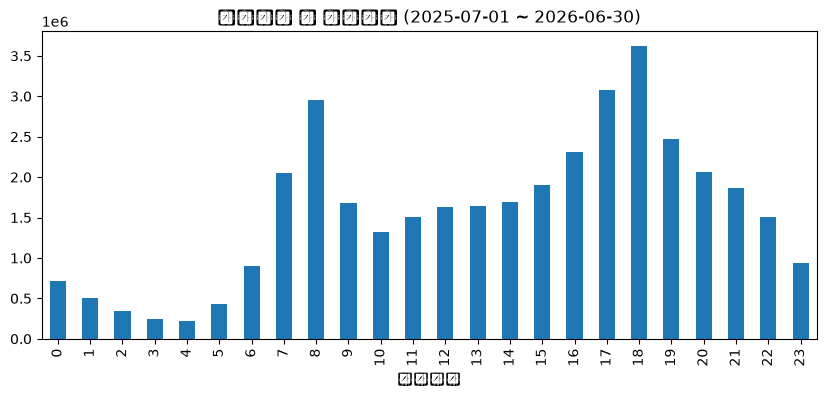

In [10]:
# 시간대별 총 이용건수
hourly = usage.groupby('대여시간')['이용건수'].sum()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar')
# ===== 수정: 6월 한정 제목을 실제 학습 기간 표시로 변경 =====
plt.title(f"시간대별 총 이용건수 ({usage['대여일자'].min()} ~ {usage['대여일자'].max()})")
# ===== 수정 끝 =====
plt.show()

In [11]:
station['rack_count'].describe()

count    1740.000000
mean       11.866667
std         6.058516
min         2.000000
25%         9.000000
50%        10.000000
75%        14.000000
max        62.000000
Name: rack_count, dtype: float64

#### 5. 전처리: 날짜+시간+대여소로 이용건수 합산

In [12]:
# 성별/연령대/대여구분 등으로 잘게 나뉜 로그를 (날짜, 시간, 대여소) 단위로 합산
agg = usage.groupby(['대여일자','대여시간','대여소번호'], as_index=False)['이용건수'].sum()
agg.columns = ['date','hour','station_id','rental_count']
agg.head()

,date,hour,station_id,rental_count
0,2025-07-01,0,103,4
1,2025-07-01,0,104,1
2,2025-07-01,0,107,1
3,2025-07-01,0,111,3
4,2025-07-01,0,113,4


#### 6. 전처리: '이용 0건'인 시간대도 포함시키기
대여 로그에는 실제로 이용이 있었던 (날짜, 시간, 대여소) 조합만 있고, 이용이 0건인 조합은 아예 행이 없어요.
이걸 그대로 학습하면 모델이 '0건'인 경우를 한 번도 못 보고 항상 과대예측하게 되니, 전체 조합 그리드를 만들어서 없는 조합은 0으로 채웁니다.

In [13]:
stations = agg['station_id'].unique()
# ===== 수정: 6월 한 달로 고정되어 있던 것을, 실제 데이터의 최소~최대 날짜로 자동 확장 =====
dates = pd.date_range(agg['date'].min(), agg['date'].max()).strftime('%Y-%m-%d')
# ===== 수정 끝 =====
hours = range(24)

grid = pd.MultiIndex.from_product([stations, dates, hours],
                                    names=['station_id','date','hour']).to_frame(index=False)
full = grid.merge(agg, on=['station_id','date','hour'], how='left')
full['rental_count'] = full['rental_count'].fillna(0).astype(int)
print(full.shape)
full.head()

(24720720, 4)


,station_id,date,hour,rental_count
0,103,2025-07-01,0,4
1,103,2025-07-01,1,6
2,103,2025-07-01,2,2
3,103,2025-07-01,3,1
4,103,2025-07-01,4,0


#### 7. 대여소 마스터와 조인 (거치대 수, 지역구 피처 추가)

In [14]:
full = full.merge(station, on='station_id', how='left')
full['rack_count'] = full['rack_count'].fillna(full['rack_count'].median())
full['district'] = full['district'].fillna('알수없음')
full['dong'] = full['dong'].fillna('알수없음')

full['date'] = pd.to_datetime(full['date'])
full['day_of_week'] = full['date'].dt.dayofweek
full['is_weekend'] = (full['day_of_week'] >= 5).astype(int)
# ===== 추가: 이제 1년치라 계절성이 존재함 -> month를 피처로 추가 =====
# (6월 한 달만 있을 땐 이 피처가 상수라서 의미가 없었지만, 1년치가 되면서 유의미해짐)
full['month'] = full['date'].dt.month
# ===== 추가 끝 =====
full.head()

,station_id,date,hour,rental_count,station_name,district,addr1,addr2,addr3,install_date,install_type,rack_count,operation_type,dong,day_of_week,is_weekend,month
0,103,2025-07-01,0,4,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
1,103,2025-07-01,1,6,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
2,103,2025-07-01,2,2,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
3,103,2025-07-01,3,1,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7
4,103,2025-07-01,4,0,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR,알수없음,1,0,7


#### 8. 범주형 인코딩

In [15]:
le = LabelEncoder()
full['district_enc'] = le.fit_transform(full['district'])

#### 9. 학습/검증 데이터 분리

In [16]:
features = ['station_id','hour','day_of_week','is_weekend','rack_count','district_enc','month']
X = full[features]
y = full['rental_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(19776576, 7) (4944144, 7)


#### 10. RandomForest 회귀 모델 학습

In [ ]:
# ===== 수정: 데이터가 12배 가까이 늘어난 만큼 트리 수/깊이를 소폭 늘림 =====
model = RandomForestRegressor(
    n_estimators=150, max_depth=16, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

#### 11. 모델 평가

In [ ]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.3f}')
print(f'R2 Score: {r2:.4f}')

# 참고: 대여소·시간 단위 이용건수는 중앙값이 1건일 정도로 변동성이 커서
# R2가 낮게 나오는 게 정상입니다 (날씨 데이터가 없는 상태의 순수 패턴 모델).


In [ ]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='barh')
plt.title('피처 중요도')
plt.gca().invert_yaxis()
plt.show()

#### 12. 모델 저장

In [ ]:
import os
os.makedirs('../models', exist_ok=True)

# ===== 수정: 파일명에 '202606'을 하드코딩하지 않고, 실제 학습에 쓰인 기간을 그대로 반영 =====
period_tag = f"{full['date'].min().strftime('%Y%m')}_{full['date'].max().strftime('%Y%m')}"
print('학습 기간 태그:', period_tag)

joblib.dump(model, f'../models/station_demand_model_{period_tag}.pkl')
joblib.dump(le, f'../models/district_encoder_{period_tag}.pkl')

station_master = station[['station_id', 'station_name', 'district', 'dong', 'rack_count']].drop_duplicates(subset='station_id')
station_master.to_csv(f'../models/station_master_{period_tag}.csv', index=False)
print('저장 완료 (대여소 수요 모델)')
station_master.sample(10, random_state=1)
# ===== 수정 끝 =====
# ⚠️ ai_station.py에서 이 파일들을 로드하는 경로도 이 period_tag로 갱신해야 합니다.
# (아래 Part 2에서 weather 모델까지 다 만든 뒤, 마지막 섹션에서 안내드릴게요.)

In [ ]:
# station = station[['station_id','district','rack_count']].drop_duplicates(subset='station_id')

---
# Part 2. 날씨 효과 모델 (1년치로 재학습, 이 노트북 안에서 투명하게)

이전에는 `weather_effect_model_202606.pkl`이 이 노트북 밖에서 별도로 만들어져서
출처를 검증할 수 없었습니다. 이제부터는 같은 원칙(원본 컬럼을 먼저 그대로 확인한 뒤 매핑)으로
이 노트북 안에서 직접 만듭니다.

필요한 것:
1. 기상청에서 받은 시간별 관측 데이터 (`../data/weather/*.csv` 등)
2. 같은 시간대의 **도시 전체 총 대여건수** — 이건 이미 위에서 만든 `agg`를 시간 단위로 합산하면 바로 나옵니다 (새로 안 받아도 됨)

#### 13. 도시 전체 시간대별 총 대여량 만들기 (Part 1의 `agg` 재사용)

In [ ]:
# agg: date, hour, station_id, rental_count (Part 1에서 이미 만든 것)
citywide = agg.groupby(['date','hour'], as_index=False)['rental_count'].sum()
citywide.columns = ['date','hour','total_rentals']
citywide['date'] = pd.to_datetime(citywide['date'])
print(citywide.shape)
citywide.head()

#### 14. 기상청 원본 데이터 확인 (컬럼명 가정하지 않고 그대로 출력)

In [ ]:
# ===== 참고: 파일이 1개(1년치 전부)든 여러 개(월별)든 아래 코드는 그대로 동작합니다 =====
# glob 패턴에 맞는 파일을 찾아서 전부 이어붙이는 방식이라, 파일 개수에 상관없이 동일하게 처리됩니다.
# 파일이 '../data/weather/' 폴더가 아니라 다른 위치/이름이면 아래 패턴만 실제 경로에 맞게 바꿔주세요.
weather_files = sorted(glob.glob('../data/OBS_20250701_20260731.csv'))
print(f'{len(weather_files)}개 날씨 파일 발견')
for f in weather_files:
    print(' -', f)

def _read_weather_csv(path):
    for enc in ('cp949', 'utf-8'):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('cp949/utf-8 둘 다 실패', b'', 0, 1, path)

raw_weather = pd.concat([_read_weather_csv(f) for f in weather_files], ignore_index=True)
print('\n원본 컬럼 목록:', list(raw_weather.columns))
raw_weather.head(10)

**검증 필요**: 위 셀 출력을 보고 아래 컬럼 매핑을 실제 컬럼명에 맞게 고치세요.
기상청 종관기상관측(ASOS) 시간자료의 전형적인 컬럼은
`일시`(관측시각), `기온(°C)`, `강수량(mm)`, `풍속(m/s)`, `습도(%)` 형태입니다만,
지점명이 같이 있거나 컬럼 순서가 다를 수 있으니 위 출력과 반드시 대조하세요.

In [ ]:
# ===== 아래 딕셔너리의 '원본 컬럼명' 부분을, 바로 위 셀에서 출력된 실제 컬럼명으로 바꿔주세요 =====
COLUMN_MAP = {
    '일시': 'datetime',
    '기온(°C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'wind_speed',
    '습도(%)': 'humidity',
}

missing = [k for k in COLUMN_MAP if k not in raw_weather.columns]
if missing:
    print('⚠️ 아래 컬럼을 원본에서 못 찾았습니다. COLUMN_MAP을 위 원본 컬럼 목록에 맞게 수정하세요:', missing)
else:
    weather = raw_weather[list(COLUMN_MAP.keys())].rename(columns=COLUMN_MAP)
    weather['datetime'] = pd.to_datetime(weather['datetime'])
    weather['date'] = weather['datetime'].dt.strftime('%Y-%m-%d')
    weather['date'] = pd.to_datetime(weather['date'])
    weather['hour'] = weather['datetime'].dt.hour
    # 결측 관측치(장비 점검 등으로 비는 시간)는 앞뒤 값으로 보간
    weather[['temperature','rainfall','wind_speed','humidity']] = (
        weather[['temperature','rainfall','wind_speed','humidity']].fillna(method='ffill').fillna(method='bfill')
    )
    print(weather.shape)
    weather.head()

#### 15. 도시 전체 이용량 + 날씨 병합 (날짜+시간 기준)

In [ ]:
weather_full = citywide.merge(weather[['date','hour','temperature','rainfall','wind_speed','humidity']],
                               on=['date','hour'], how='inner')
weather_full['day_of_week'] = weather_full['date'].dt.dayofweek
weather_full['is_weekend'] = (weather_full['day_of_week'] >= 5).astype(int)

print(f'병합 전 이용량 데이터: {len(citywide)}행, 병합 후: {len(weather_full)}행')
if len(weather_full) < len(citywide) * 0.9:
    print('⚠️ 병합 후 행이 많이 줄었습니다 — 이용 로그 기간과 날씨 데이터 기간이 서로 안 맞을 수 있어요.')
    print('이용 로그 기간:', citywide['date'].min(), '~', citywide['date'].max())
    print('날씨 데이터 기간:', weather['date'].min(), '~', weather['date'].max())

weather_full.head()

#### 16. 날씨 효과 모델 학습

In [ ]:
weather_features = ['hour','day_of_week','is_weekend','temperature','rainfall','wind_speed','humidity']
Xw = weather_full[weather_features]
yw = weather_full['total_rentals']

Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, random_state=42)

weather_model = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
weather_model.fit(Xw_train, yw_train)

wpred = weather_model.predict(Xw_test)
print(f'날씨 모델 MAE: {mean_absolute_error(yw_test, wpred):.2f}')
print(f'날씨 모델 R2: {r2_score(yw_test, wpred):.4f}')

#### 17. 학습 범위 직접 확인 (지난번처럼 '조용히 뭉개지는 구간'이 남아있는지 점검)

1년치로 늘었으니 이전(22~32℃만 반응)보다 범위가 넓어졌는지, 온도를 촘촘히 훑어서 직접 확인합니다.

In [ ]:
probe_hour, probe_dow = 18, 2
for t in range(int(weather_full['temperature'].min()) - 5, int(weather_full['temperature'].max()) + 6, 2):
    row = pd.DataFrame([{
        'hour': probe_hour, 'day_of_week': probe_dow, 'is_weekend': 0,
        'temperature': t, 'rainfall': 0, 'wind_speed': 2.0, 'humidity': 50,
    }])
    pred = weather_model.predict(row[weather_features])[0]
    print(f'{t:>4}℃ -> {pred:.1f}')

print('\n실제 학습 데이터의 기온 범위:', weather_full['temperature'].min(), '~', weather_full['temperature'].max())

#### 18. 날씨 없는 기준선(baseline) 재계산 — hour × is_weekend 평균

In [ ]:
weather_reference = citywide.copy()
weather_reference['day_of_week'] = weather_reference['date'].dt.dayofweek
weather_reference['is_weekend'] = (weather_reference['day_of_week'] >= 5).astype(int)
weather_reference = (
    weather_reference.groupby(['hour','is_weekend'], as_index=False)['total_rentals'].mean()
)
print(weather_reference.shape)  # 24시간 x 2(평일/주말) = 48행이어야 정상
weather_reference.head()

#### 19. 날씨 모델 저장

In [ ]:
joblib.dump(weather_model, f'../models/weather_effect_model_{period_tag}.pkl')
weather_reference.to_csv(f'../models/weather_reference_{period_tag}.csv', index=False)
print('저장 완료 (날씨 효과 모델):', period_tag)

#### 20. `ai_station.py`에 반영할 것

파일명이 더 이상 `_202606`이 아니라 `_{period_tag}`(예: `_202507_202606`)로 바뀌었으니,
`ai_station.py`의 아래 세 줄을 새 파일명으로 갱신해야 합니다.

```python
_station_model = joblib.load(ML_DIR / "station_demand_model_XXXXXX_XXXXXX.pkl")
_district_encoder = joblib.load(ML_DIR / "district_encoder_XXXXXX_XXXXXX.pkl")
_weather_model = joblib.load(ML_DIR / "weather_effect_model_XXXXXX_XXXXXX.pkl")
_weather_ref = pd.read_csv(DATA_DIR / "weather_reference_XXXXXX_XXXXXX.csv")
_station_master = pd.read_csv(DATA_DIR / "station_master_XXXXXX_XXXXXX.csv")
```

그리고 `_station_model.feature_names_in_`에 이제 `month`가 추가됐으니,
`_predict_station_demand`/`_station_hourly_curve`에서 `station_input`을 만들 때
`"month": date.month`를 같이 넣어줘야 합니다 (안 넣으면 `feature_names_in_` 불일치로 에러가 납니다).
이 부분은 실제 노트북 실행 결과(위 20번 셀까지의 출력, 특히 17번 셀의 온도별 반응 결과와 기상 데이터 병합 행 수)를
보내주시면, `ai_station.py` 수정본까지 바로 만들어드릴게요.